In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


# Interpolation #

@autor:     Dario Hug

@date:      18.11.2024

**Assignment**: 

- Trace the movement of electrons in the electromagnetic potential from the last exercise with an integrator (Leapfrog, RK4). Use bilinear interpolation for the potential.
- The domain has the size of 0.01m in both dimensions, the electrons start at x=0 and y=0.007...0.009. The detector is at x=0.01 and y=0.001...0.003.
- Create a plot showing the paths of the electrons in the potential.
- Create histograms showing the arrival time and arrival position distribution.
- Use bicubic interpolation and check if this makes any difference.

Then, use this to design an optimal electron detector. Optimize the detector design such that the most electrons hit the detector and the scatter in flight time is the smallest.

In [3]:
def SOR_checkerboard(U, tolerance, max_iterations, omega, grid_elements):

    U_new = np.ones_like(U)
    magnitude_grid = np.ones_like(U)  # We store the Updates

    # We create checkerboard pattern for r/b cells
    checker_bool_grid = np.ones_like(U, dtype=bool)
    for x, y in np.ndindex(U.shape):
        checker_bool_grid[x, y] = (x % 2 == y % 2)

    # Mask of grid center where we dont want to change values
    center_bool_grid = np.ones_like(U, dtype=bool)
    for x, y in np.ndindex(U.shape):
        center_bool_grid[x, y] = (x, y) not in grid_elements

    diff = np.max(np.abs(magnitude_grid))
    nsteps = 0

    while diff >= tolerance and nsteps < max_iterations:
        magnitude_grid = np.zeros_like(U)

        red_update_mask = np.logical_and(checker_bool_grid, center_bool_grid)
        black_update_mask = np.logical_and(~checker_bool_grid, center_bool_grid)

        # Apply convolution for red points
        ndimage.convolve(U, np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]), output=U_new, mode="constant", cval=0)
        magnitude_grid[red_update_mask] = 0.25 * U_new[red_update_mask]
        U[red_update_mask] += omega * magnitude_grid[red_update_mask]  

        # Now the black points
        ndimage.convolve(U, np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]), output=U_new, mode="constant", cval=0)
        magnitude_grid[black_update_mask] = 0.25 * U_new[black_update_mask]
        U[black_update_mask] += omega * magnitude_grid[black_update_mask] 

        diff = np.max(np.abs(magnitude_grid))

        nsteps += 1

    return U

In [4]:
def illustrate_electric_fields_and_paths(U_sor, xdata, ydata, force_x_ls, force_y_ls, t_hist, y_hist):
    plt.figure(figsize=(20, 12))
    
    plt.subplot(2, 2, 1)
        
    plt.contourf(U_sor.T, 50, cmap="inferno", extent=[0, 0.01, 0, 0.01])
    plt.title("Electron Paths and Forces as Vectors")

    for i in range(len(xdata)):
        plt.plot(xdata[i], ydata[i], color="cyan", linewidth=1.2)
        for j in range(len(xdata[i])-1):
                if (
                    j % 100 == 0 and 
                    0 <= xdata[i][j] + force_x_ls[i][j] * 3e-20 <= 0.0095 and 
                    0 <= ydata[i][j] + force_y_ls[i][j] * 3e-20 <= 0.0095
                ):  
                    plt.arrow(xdata[i][j], ydata[i][j], force_x_ls[i][j]*3e-20, force_y_ls[i][j]*3e-20, width=1e-4,
                            head_width=2e-4, head_length=3e-4, fc='magenta', ec='magenta', length_includes_head=False)

    plt.plot([0.01, 0.0105], [0.001, 0.001], color='black', linestyle='-', linewidth=3)
    plt.plot([0.01, 0.0105], [0.003, 0.003], color='black', linestyle='-', linewidth=3)

    plt.plot([-0.0005, 0.0], [0.007, 0.007], color='black', linestyle='-', linewidth=3)
    plt.plot([-0.0005, 0.0], [0.009, 0.009], color='black', linestyle='-', linewidth=3)
    
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    
    plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)

    plt.subplot(2, 2, 2)
    plt.contourf(U_sor.T, 80, cmap="inferno", extent=[0, 0.01, 0, 0.01])
    plt.colorbar(label="Voltage (V)")
    plt.title(f"Electric Field")
    plt.plot(xdata[-1], ydata[-1], color="cyan", linewidth=1.2)
    for j in range(len(xdata[-1])-1):
            if (
                j % 100 == 0 and 
                0 <= xdata[-1][j] + force_x_ls[-1][j] * 3e-20 <= 0.0095 and 
                0 <= ydata[-1][j] + force_y_ls[-1][j] * 3e-20 <= 0.0095
            ):  
                plt.arrow(xdata[-1][j], ydata[-1][j], force_x_ls[-1][j]*3e-20, force_y_ls[-1][j]*3e-20, width=1e-4,
                        head_width=2e-4, head_length=3e-4, fc='magenta', ec='magenta', length_includes_head=False)

    t_true = [t[0] for t in t_hist if t[1]]
    
    plt.subplot(2, 2, 3)
    plt.hist(t_true, bins=60, color='blue', alpha=0.7, label="Hit Detector")
    plt.xlabel("Detection Time (s)")
    plt.ylabel("# of e⁻")
    if t_true:
        spread = max(t_true) - min(t_true)
        plt.title(f"Electron Detection Times, range: {spread:.3}s")
    else:
        plt.title(f"Electron Detection Times, range: Error")
    
    plt.legend()

    # Histogram for y-coordinates at detection
    plt.subplot(2, 2, 4)
    plt.hist(y_hist, bins=60, color='green', edgecolor='black', alpha=0.7)
    plt.xlabel("y-coordinate (m)")
    plt.ylabel("# of e⁻")
    if t_true:
        eff = len(t_true) / len(t_hist) * 100
        plt.title(f"y-Positions at hit, Efficiency: {eff}%")
    else: 
        plt.title(f"y-Positions at hit, Efficiency: 0%")

    plt.tight_layout()
    plt.show()


**Bilenar Interpolation:**

$ \phi(x, y) = (1-u)(1-t)\phi _1 + (1-u)t\phi _2 + u(1-t)\phi _3 + ut\phi _4 $


$ \frac{\partial \phi}{\partial x} \Bigr\rvert_{u} = \frac{1}{\triangle} [(1-u)(\phi _2 - \phi _1) + u(\phi _4 - \phi _3) ] $

$ \frac{\partial \phi}{\partial y} \Bigr\rvert_{t} = \frac{1}{\triangle} [(1-t)(\phi _3 - \phi _1) + t(\phi _4 - \phi _2) ] $ 

$ \dot v_x = (\frac{e}{m_e})[- \frac{1}{\triangle} ((1-u)(\phi _2 - \phi _1) + u(\phi _4 - \phi _3))] $ 

$ \dot v_y = (\frac{e}{m_e})[- \frac{1}{\triangle} ((1-t)(\phi _3 - \phi _1) + u(\phi _4 - \phi _2))] $ 


In [ ]:
def calculate_electron_paths(grid_elements, n_elec, U, N):

    tolerance = 1e-3
    max_iterations = 10000
    omega = 1.5

    for node in grid_elements.keys():
        U[node[0], node[1]] = grid_elements[node]

    U = SOR_checkerboard(U.copy(), tolerance, max_iterations, omega, grid_elements)

    #dimension of grid
    dim = 0.01 #in m
    delta = dim/(N - 1)

    def getindex(x,y):
        j = np.array(x/delta, dtype="int")
        l = np.array(y/delta, dtype="int")
        return(j,l)

    #interpolation
    def accel(x,y,U):
        j, l = getindex(x,y)
        J, L = U.shape
        
        j = np.maximum(j, np.zeros_like(j))
        j = np.minimum(j, (J-2)*np.ones_like(j))
        l = np.maximum(l, np.zeros_like(l))
        l = np.minimum(l, (L-2)*np.ones_like(l))
        
        t = (x - j*delta)/delta
        u = (y - l*delta)/delta

        phi_1 = U[j, l]
        phi_2 = U[j+1, l]
        phi_3 = U[j, l+1]
        phi_4 = U[j+1, l+1]

        # Bilinear: 
        ax = (e / me) * ((-1/delta) * ((1-u)*(phi_2 - phi_1) + u*(phi_4 - phi_3)))
        ay = (e / me) * ((-1/delta) * ((1-t)*(phi_3 - phi_1) + t*(phi_4 - phi_2)))
        
        return ax, ay

    def leapfrog(x, y, vx, vy, h, U):
        ax, ay = accel(x, y, U)
        force_x = ax
        force_y = ay
        vx += h * (1/2)*ax              # Half Drift
        vy += h * (1/2)*ay
        x += vx * h                     #Kick
        y += vy * h
        ax, ay = accel(x, y, U)         
        vx += h* (1/2)*ax               #second half of Drift
        vy += h* (1/2)*ay
        return x, y, vx, vy, force_x, force_y

    e = -1.60e-19
    me = 9.11e-31

    h = 1e-12
    tEnd = 0.1


    x = np.zeros(n_elec) 
    y = np.linspace(0.007,0.009,n_elec)

    v = 1e6 #m/s -> speed of electron 

    vy = np.random.uniform(-v,v,n_elec)
    vx = np.sqrt(np.ones(n_elec)*v**2-vy**2)

    # Containers for final paths
    xdata_ls = [[] for _ in range(n_elec)]
    ydata_ls = [[] for _ in range(n_elec)]
    force_x_ls = [[] for _ in range(n_elec)]
    force_y_ls = [[] for _ in range(n_elec)]


    t_hist = []
    y_hist = []

    

    for i in range(int(tEnd/h)):
        x, y, vx, vy, force_x, force_y = leapfrog(x, y, vx, vy, h, U.copy())
        t = i * h

        for j in range(n_elec):
            
            if not np.isnan(x[j]) and not np.isnan(y[j]):
                xdata_ls[j].append(x[j])
                ydata_ls[j].append(y[j])
                force_x_ls[j].append(force_x[j])  # Store the force
                force_y_ls[j].append(force_y[j])
            
            if x[j] >= 0.01 and y[j] >= 0.001 and y[j] <= 0.003:        #Electron hit detector 
                t_hist.append((t, True))
                y_hist = np.append(y_hist, y[j])
                x[j] = np.nan
                y[j] = np.nan

            elif x[j] < 0 or x[j] > 0.01 or y[j] < 0 or y[j] > 0.01:    #Electron hit wall
                t_hist.append((t, False))
                if x[j] >= 0.01:
                    y_hist = np.append(y_hist, y[j])
                else:
                    y_hist = np.append(y_hist, 0.01)
                x[j] = np.nan
                y[j] = np.nan

        if np.all(np.isnan(x)) and np.all(np.isnan(y)):
            break

    return U, xdata_ls, ydata_ls, t_hist, y_hist, force_x_ls, force_y_ls

### Layout using Electric Force in front of Detector ###

In this Setup I've used a electron permeable element right in front of the detector effectively disconnecting the detector from GND and setting it 500V. This yields very nice results in the simulator but I'm affraid that it would cause problems in the real world, where electron sensors can be very fragile. 

In [ ]:
N = 100
U = np.zeros((N, N))
n_elec = 100

grid_elements = {}

regions = [

    ((lambda x, y: 20 < x < 30 and 40 < y < 50), 500),
    
    ((lambda x, y: 65 < x < 70 and 35 < y < 40), 300),
    
    ((lambda x, y: 90 < x < 100 and 10 < y < 28), 500),
    
    ((lambda x, y: 50 < x < 55 and 90 < y < 100), -50), 

    ((lambda x, y: 30 < x < 35 and 3 < y < 15), -50), 

    ((lambda x, y: 80 < x < 95 and 39.5 < y < 43), -50), 
]

for x, y in np.ndindex(U.shape):
    for condition, value in regions: 
        if condition(x, y):  #Pass x, y to lambda function
            grid_elements[(x, y)] = value

U, xdata_ls, ydata_ls, t_hist, y_hist, force_x_ls, force_y_ls = calculate_electron_paths(grid_elements, n_elec, U, N)



/tmp/ipykernel_35932/929264767.py:17: RuntimeWarning: invalid value encountered in cast
  j = np.array(x/delta, dtype="int")
/tmp/ipykernel_35932/929264767.py:18: RuntimeWarning: invalid value encountered in cast
  l = np.array(y/delta, dtype="int")


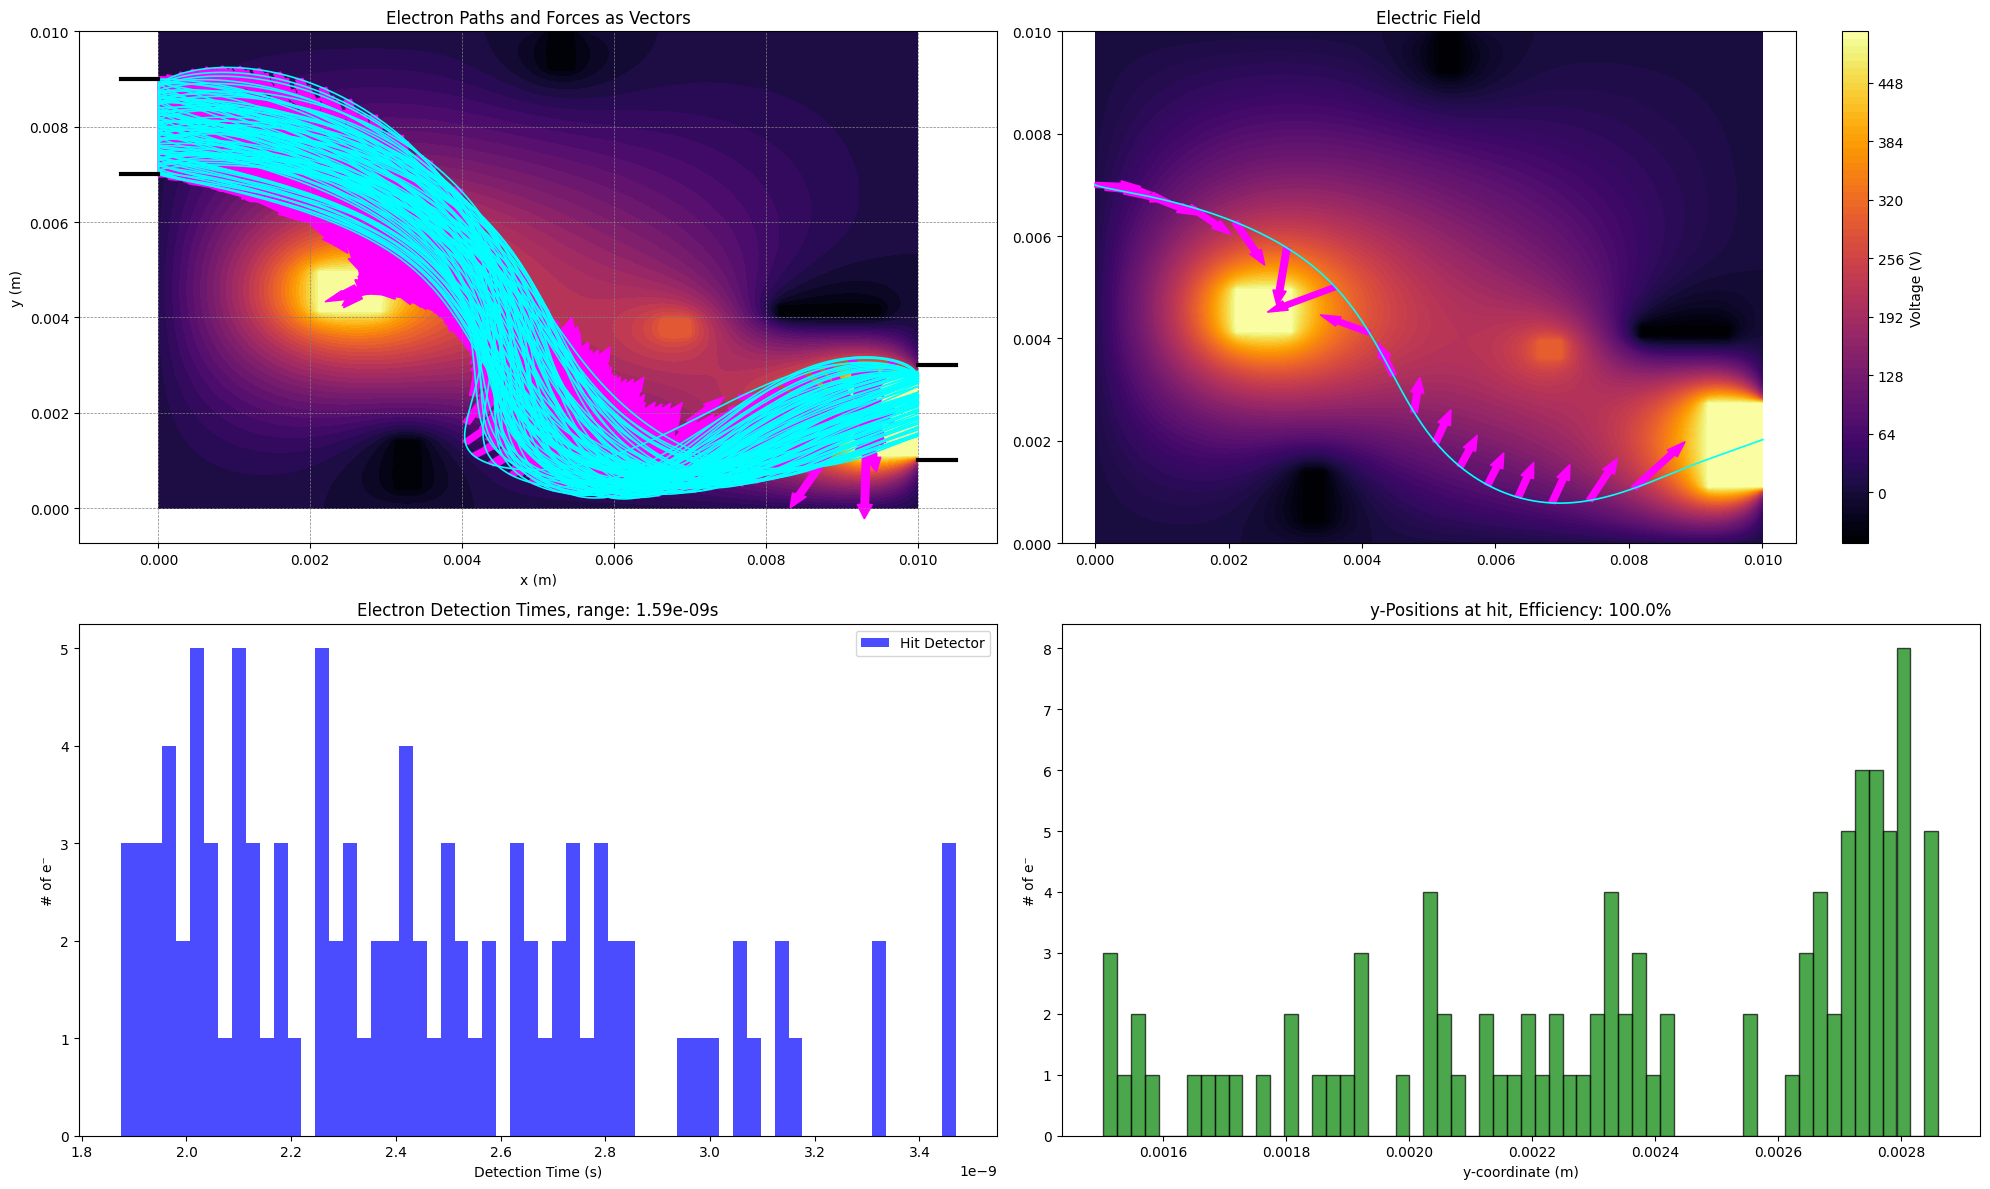

In [11]:
illustrate_electric_fields_and_paths(U, xdata_ls, ydata_ls, force_x_ls, force_y_ls, t_hist, y_hist)

### A more realistic Approach ###

In this Setup I've made some smaller adjustments, mainly moving the forcefield further away from the detector. This way, the detector is less affected by the electric field. This causes the efficiency to drop from 100% to around 80%. Also due to more variation in the elctron paths, the spread in detector-hit-times roughly doubled. 

/tmp/ipykernel_4534/4278271396.py:17: RuntimeWarning: invalid value encountered in cast
  j = np.array(x/delta, dtype="int")
/tmp/ipykernel_4534/4278271396.py:18: RuntimeWarning: invalid value encountered in cast
  l = np.array(y/delta, dtype="int")


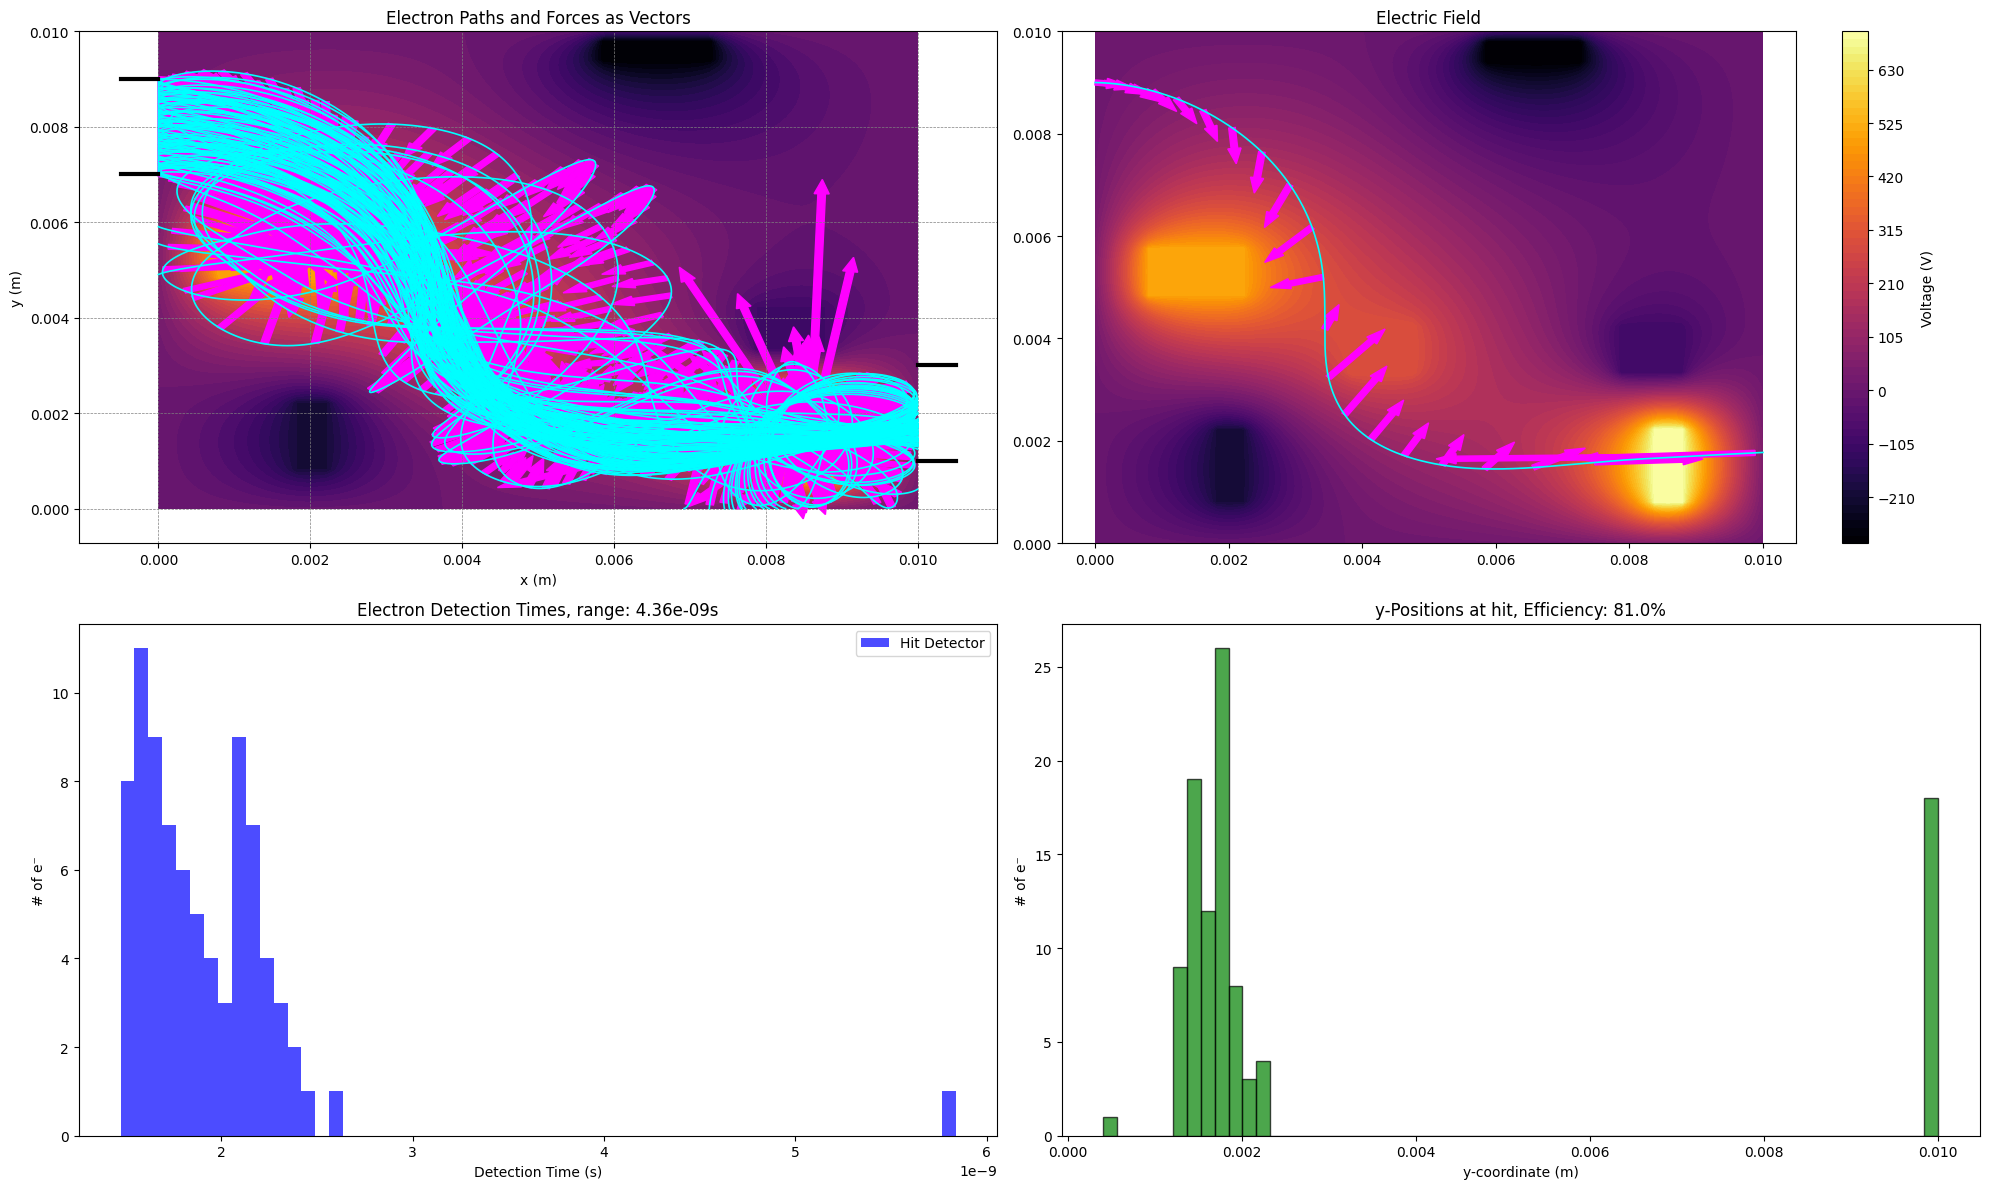

In [64]:
N = 100
U = np.zeros((N, N))
n_elec = 100

grid = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -3, -3, -3, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0],
    [0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0],
    [0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0]
]

regions = []
for iy, row in enumerate(grid):
    for ix, column in enumerate(row):
        if column != 0:
            # Define a rule with a lambda for the position and its associated value
            rule = (lambda x, y, ix=ix, iy=iy: (ix * 5 - 2) <= x <= (ix * 5 + 2) and ((19 - iy) * 5 - 2) <= y <= ((19 - iy) * 5 + 2), column * 100)
            regions.append(rule)

# Populate grid_elements dictionary with values based on regions
grid_elements = {}
for x, y in np.ndindex(U.shape):
    for condition, value in regions:
        if condition(x, y):
            grid_elements[(x, y)] = value

U, xdata_ls, ydata_ls, t_hist, y_hist, force_x_ls, force_y_ls = calculate_electron_paths(grid_elements, n_elec, U, N)

illustrate_electric_fields_and_paths(U, xdata_ls, ydata_ls, force_x_ls, force_y_ls, t_hist, y_hist)

### A wild Idea ###

In this version I thought about using more unconventional Ideas. Here I tried to "shoot" the electron into the detector by first atracting it closely to a strong negativ field which then acts on the electron with extreme force. In the plot with the single electron path it is visible by the spacing of the froce vectors, that the electron experiences a crazy accelaration. I dont think that this aproach qould yield great results in a real world setup. 

/tmp/ipykernel_4534/4278271396.py:17: RuntimeWarning: invalid value encountered in cast
  j = np.array(x/delta, dtype="int")
/tmp/ipykernel_4534/4278271396.py:18: RuntimeWarning: invalid value encountered in cast
  l = np.array(y/delta, dtype="int")


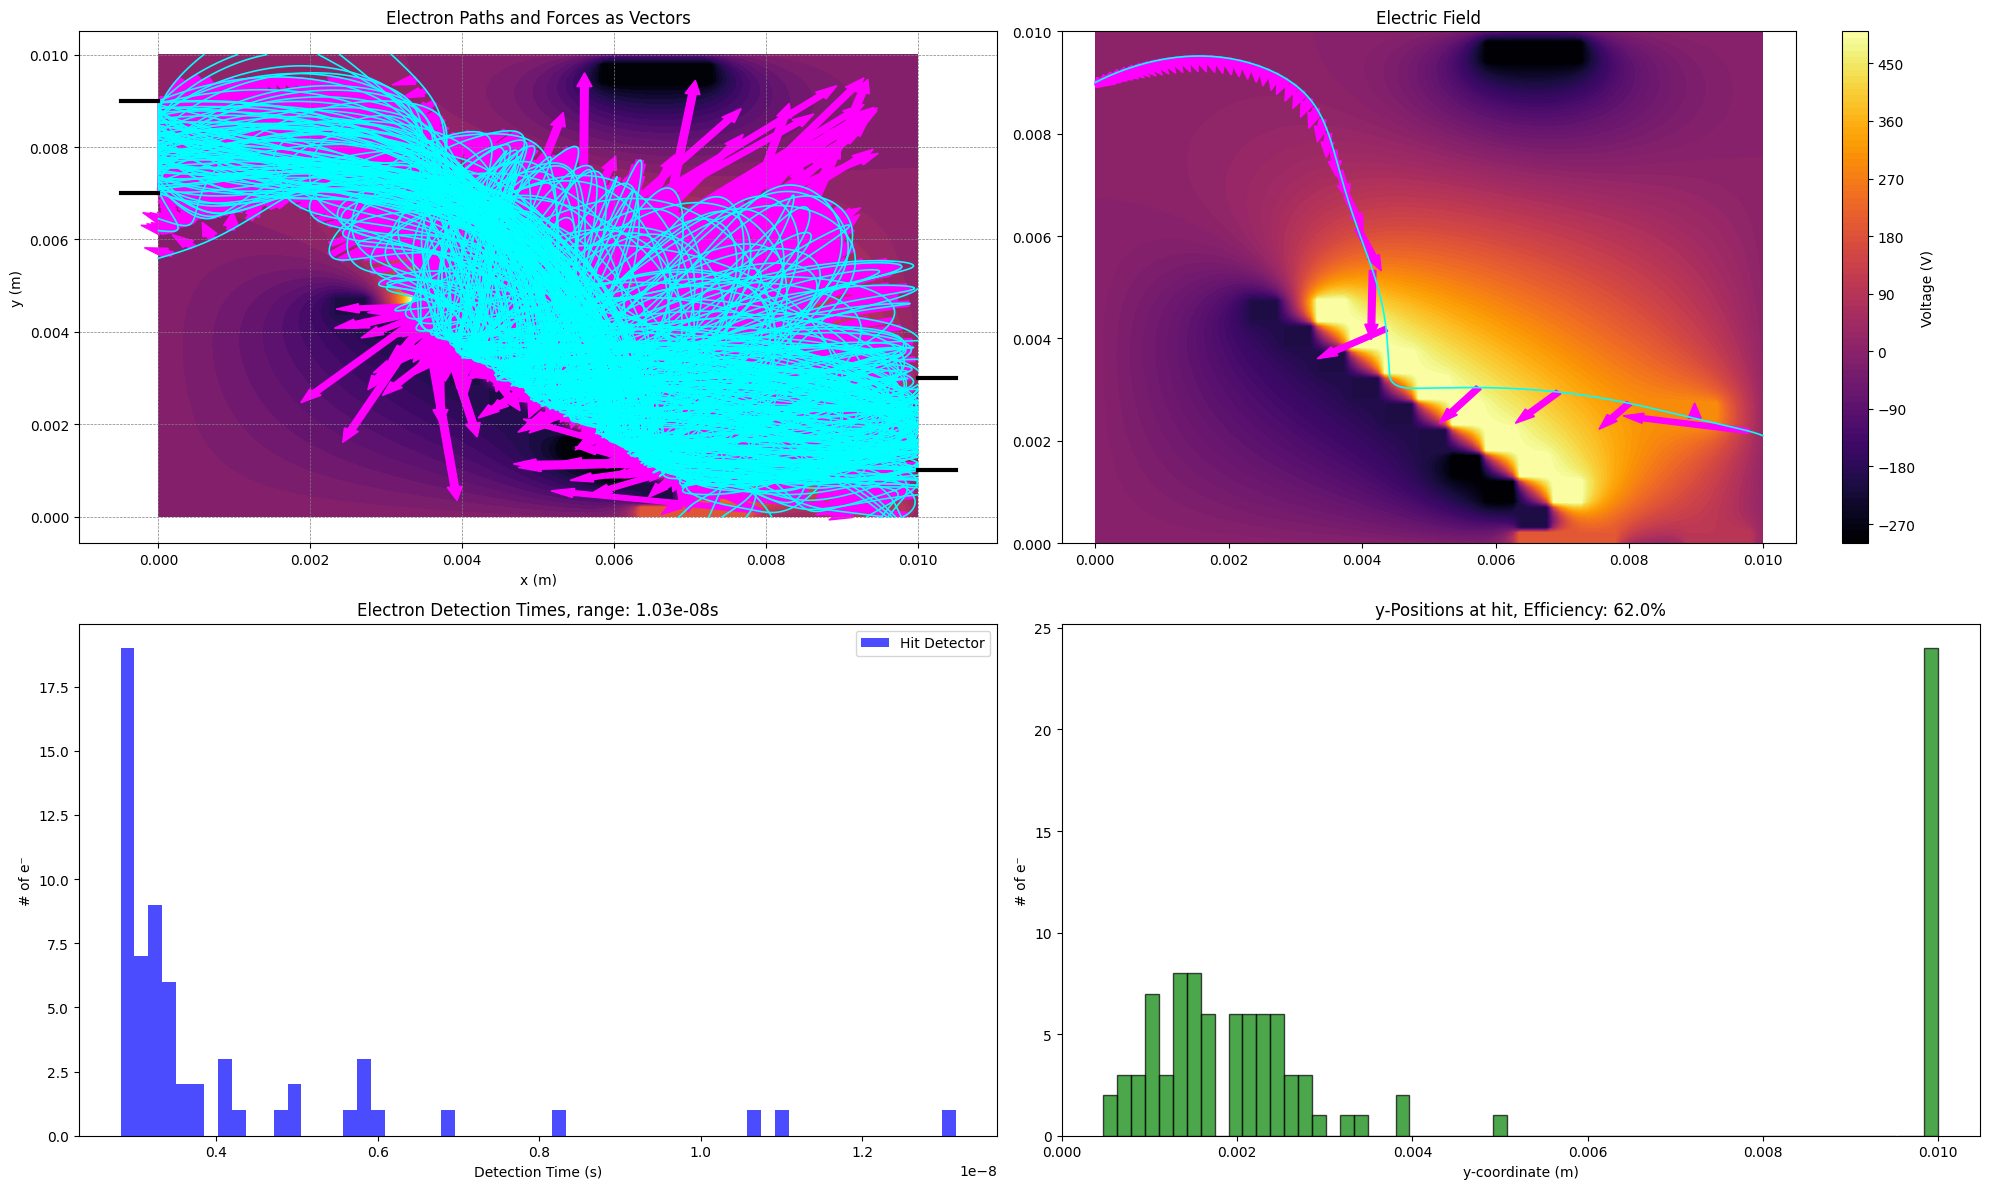

In [70]:
N = 100
U = np.zeros((N, N))
n_elec = 100

grid = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -3, -3, -3, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, -2, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, -2, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, -2, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, -2, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, -2, 0, 5, 0, 0, 0, 0, 0, 3, 3, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2, 0, 5, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -3, 0, 5, 0, 0, 0, 0, 0, 0],    
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -3, 0, 5, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 1, 1]
]


regions = []
for iy, row in enumerate(grid):
    for ix, column in enumerate(row):
        if column != 0:
            # Define a rule with a lambda for the position and its associated value
            rule = (lambda x, y, ix=ix, iy=iy: (ix * 5 - 2) <= x <= (ix * 5 + 2) and ((19 - iy) * 5 - 2) <= y <= ((19 - iy) * 5 + 2), column * 100)
            regions.append(rule)

# Populate grid_elements dictionary with values based on regions
grid_elements = {}
for x, y in np.ndindex(U.shape):
    for condition, value in regions:
        if condition(x, y):
            grid_elements[(x, y)] = value

U, xdata_ls, ydata_ls, t_hist, y_hist, force_x_ls, force_y_ls = calculate_electron_paths(grid_elements, n_elec, U, N)

illustrate_electric_fields_and_paths(U, xdata_ls, ydata_ls, force_x_ls, force_y_ls, t_hist, y_hist)

## Now the Bicubic Interpolation ##

### Bicubic Coefficients

The bicubic coefficients are computed using the formula:

$
\phi(x, y) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} t^i u^j,
$

where:
$ t = \frac{x - x_j}{\Delta x} $, $ u = \frac{y - y_l}{\Delta y} $


$
  \mathbf{F} =
  \begin{bmatrix}
  \phi_{1} & \phi_{2} & \phi_{y1} & \phi_{y2} \\
  \phi_{3} & \phi_{4} & \phi_{y3} & \phi_{y4} \\
  \phi_{x,1} & \phi_{x,2} & \phi_{1, xy} & \phi_{2, xy} \\
  \phi_{x,3}  & \phi_{x,4}  & \phi_{3, xy} & \phi_{4, xy}
  \end{bmatrix}.
$

$
  \mathbf{M} =
  \begin{bmatrix}
  1 & 0 & -3 & 2 \\
  0 & 1 & 3 & -2 \\
  0 & 1 & -2 & 1 \\
  0 & 0 & -1 & 1
  \end{bmatrix}
$

The coefficients $ c_{ij} $ are calculated as:
$
\mathbf{C} = \mathbf{M} \cdot \mathbf{F} \cdot \mathbf{M^T}
$

$ \phi(t, u) = [1, t, t², t3] * [a_{i,j}] - \begin{bmatrix} 1 \\ u \\ u² \\ u³ \end{bmatrix} $ 



### Bicubic Acceleration ###

$ a_x = -\frac{e}{m_e \Delta x} \sum_{i=1}^{3} \sum_{j=0}^{3} a_{ij} t^{i-1} u^j $

$ a_y = -\frac{e}{m_e \Delta y} \sum_{i=0}^{3} \sum_{j=1}^{3} a_{ij} t^i u^{j-1}.$


### Hermantic Functions ###

$ h_0​(t) = 2t^3−3t^2+1 $ 

$ h_1(t) = −2t^3+3t^2 $ 

$ h_2(t) = t^3−2^t2+t $ 

$ h_3(t) = t^3−t^2 $ 

### Hermantic Functions Derivatives ###

$ h_0′​(t) = 6t^2−6t $ 

$ h_1′(t) = −6t^2+6t $ 
 
$ h_2′(t) = 3t^2−4t+1 $ 

$ h_3′(t) = 3t^2−2t $





In [ ]:
e = -1.60e-19
me = 9.11e-31

h = 1e-12
tEnd = 0.1

def getindex(x, y, delta):
    j = int(x / delta)
    l = int(y / delta)
    return j, l

def hermite_basis(t):
    h0 = 1 - 3 * t**2 + 2 * t**3
    h1 = t - 2 * t**2 + t**3
    h2 = 3 * t**2 - 2 * t**3
    h3 = -t**2 + t**3
    return np.array([h0, h1, h2, h3])

def hermite_basis_derivative(t):
    h0_prime = -6 * t + 6 * t**2
    h1_prime = 1 - 4 * t + 3 * t**2
    h2_prime = 6 * t - 6 * t**2
    h3_prime = -2 * t + 3 * t**2
    return np.array([h0_prime, h1_prime, h2_prime, h3_prime])

def hermite_coefficients(U, delta):
    J, L = U.shape
    coeffs = np.zeros((J, L, 16))

    # Hermite coefficient calculation matrix
    M = np.array([
        [1, 0, -3, 2],
        [0, 1, 3, -2],
        [0, 0, -3, 2],
        [0, 0, 3, -2],
    ])

    # Excluding boundaries
    for j in range(1, J - 2):
        for l in range(1, L - 2):

            # Extracting grid values and derivatives
            f00 = U[j, l]
            f10 = U[j + 1, l]
            f01 = U[j, l + 1]
            f11 = U[j + 1, l + 1]

            fx00 = (U[j + 1, l] - U[j - 1, l]) 
            fx10 = (U[j + 2, l] - U[j, l]) 
            fx01 = (U[j + 1, l + 1] - U[j - 1, l + 1]) 
            fx11 = (U[j + 2, l + 1] - U[j, l + 1]) 

            fy00 = (U[j, l + 1] - U[j, l - 1]) 
            fy10 = (U[j + 1, l + 1] - U[j + 1, l - 1]) 
            fy01 = (U[j, l + 2] - U[j, l]) 
            fy11 = (U[j + 1, l + 2] - U[j + 1, l]) 

            fxy00 = (U[j + 1, l + 1] - U[j - 1, l + 1] - U[j + 1, l - 1] + U[j - 1, l - 1]) 
            fxy10 = (U[j + 2, l + 1] - U[j, l + 1] - U[j + 2, l - 1] + U[j, l - 1]) 
            fxy01 = (U[j + 1, l + 2] - U[j - 1, l + 2] - U[j + 1, l] + U[j - 1, l]) 
            fxy11 = (U[j + 2, l + 2] - U[j, l + 2] - U[j + 2, l] + U[j, l]) 

            # Matrix of values and derivatives
            F = np.array([
                [f00, f01, fy00, fy01],
                [f10, f11, fy10, fy11],
                [fx00, fx01, fxy00, fxy01],
                [fx10, fx11, fxy10, fxy11],
            ])

            coeff_matrix = M.T @ F @ M
            coeffs[j, l] = coeff_matrix.flatten()

    return coeffs

def accel_bicubic(x, y, U, coeffs, delta):
    J, L = U.shape
    ax = np.zeros_like(x)
    ay = np.zeros_like(y)

    for idx in range(len(x)):
        if np.isnan(x[idx]) or np.isnan(y[idx]):
            continue

        # Index and normalization
        j, l = getindex(x[idx], y[idx], delta)
        j = np.clip(j, 1, J - 2)
        l = np.clip(l, 1, L - 2)

        t = (x[idx] - j * delta) / delta
        u = (y[idx] - l * delta) / delta

        c = coeffs[j, l]

        phi = 0
        dphidx = 0
        dphidy = 0

        # Hermite basis and derivatives
        h_t = hermite_basis(t)
        h_u = hermite_basis(u)
        dh_t = hermite_basis_derivative(t)
        dh_u = hermite_basis_derivative(u)

        for i in range(4):
            for j in range(4):
                phi += c[i * 4 + j] * h_t[i] * h_u[j]
                dphidx += c[i * 4 + j] * dh_t[i] * h_u[j] / delta
                dphidy += c[i * 4 + j] * h_t[i] * dh_u[j] / delta

        ax[idx] = -(e / me) * dphidx
        ay[idx] = -(e / me) * dphidy

    return ax, ay

def leapfrog(x, y, vx, vy, h, U, coeffs, delta):
    ax, ay = accel_bicubic(x, y, U, coeffs, delta)

    vx += h * 0.5 * ax  # Half drift
    vy += h * 0.5 * ay
    x += vx * h         # Kick
    y += vy * h

    ax, ay = accel_bicubic(x, y, U, coeffs, delta)
    
    vx += h * 0.5 * ax  # Second half drift
    vy += h * 0.5 * ay

    return x, y, vx, vy, ax, ay


def calculate_electron_paths_bicubic(grid_elements, n_elec, U, N):

    tolerance = 1e-3
    max_iterations = 10000
    omega = 1.5

    for node in grid_elements.keys():
        U[node[0], node[1]] = grid_elements[node]

    U = SOR_checkerboard(U.copy(), tolerance, max_iterations, omega, grid_elements)

    #dimension of grid
    delta = 0.01 / N

    coeffs = hermite_coefficients(U, delta)

    x = np.zeros(n_elec) 
    y = np.linspace(0.007,0.009,n_elec)

    v = 1e6 #m/s -> speed of electron 

    vy = np.random.uniform(-v,v,n_elec)
    vx = np.sqrt(np.ones(n_elec)*v**2-vy**2)

    # Containers for final paths
    xdata_ls = [[] for _ in range(n_elec)]
    ydata_ls = [[] for _ in range(n_elec)]
    force_x_ls = [[] for _ in range(n_elec)]
    force_y_ls = [[] for _ in range(n_elec)]


    t_hist = []
    y_hist = []

    for i in range(int(tEnd/h)):
        x, y, vx, vy, force_x, force_y = leapfrog(x, y, vx, vy, h, U, coeffs, delta)
        t = i * h

        for j in range(n_elec):
            
            if not np.isnan(x[j]) and not np.isnan(y[j]):
                xdata_ls[j].append(x[j])
                ydata_ls[j].append(y[j])
                force_x_ls[j].append(force_x[j])  # Store the force
                force_y_ls[j].append(force_y[j])
            
            if x[j] >= 0.01 and y[j] >= 0.001 and y[j] <= 0.003:        #Electron hit detector 
                t_hist.append((t, True))
                y_hist = np.append(y_hist, y[j])
                x[j] = np.nan
                y[j] = np.nan

            elif x[j] < 0 or x[j] > 0.01 or y[j] < 0 or y[j] > 0.01:    #Electron hit wall
                t_hist.append((t, False))
                if x[j] >= 0.01:
                    y_hist = np.append(y_hist, y[j])
                else:
                    y_hist = np.append(y_hist, 0.01)
                x[j] = np.nan
                y[j] = np.nan

        if np.all(np.isnan(x)) and np.all(np.isnan(y)):
            break

    return U, xdata_ls, ydata_ls, t_hist, y_hist, force_x_ls, force_y_ls

Unfortunatly no matter what i tried, i did not manage to get this to work properly. There must be something wrong in the implementation of my math or in my math itself.

In [228]:
N = 100
U = np.zeros((N, N))
n_elec = 100

grid = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -3, -3, -3, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, -1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0],
    [0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0],
    [0, 0, 0, 0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0]
]

regions = []
for iy, row in enumerate(grid):
    for ix, column in enumerate(row):
        if column != 0:
            # Define a rule with a lambda for the position and its associated value
            rule = (lambda x, y, ix=ix, iy=iy: (ix * 5 - 2) <= x <= (ix * 5 + 2) and ((19 - iy) * 5 - 2) <= y <= ((19 - iy) * 5 + 2), column * 100)
            regions.append(rule)

# Populate grid_elements dictionary with values based on regions
grid_elements = {}
for x, y in np.ndindex(U.shape):
    for condition, value in regions:
        if condition(x, y):
            grid_elements[(x, y)] = value
U_bicubic, xdata_ls, ydata_ls, t_hist, y_hist, force_x_ls, force_y_ls = calculate_electron_paths_bicubic(grid_elements, n_elec,U, N)


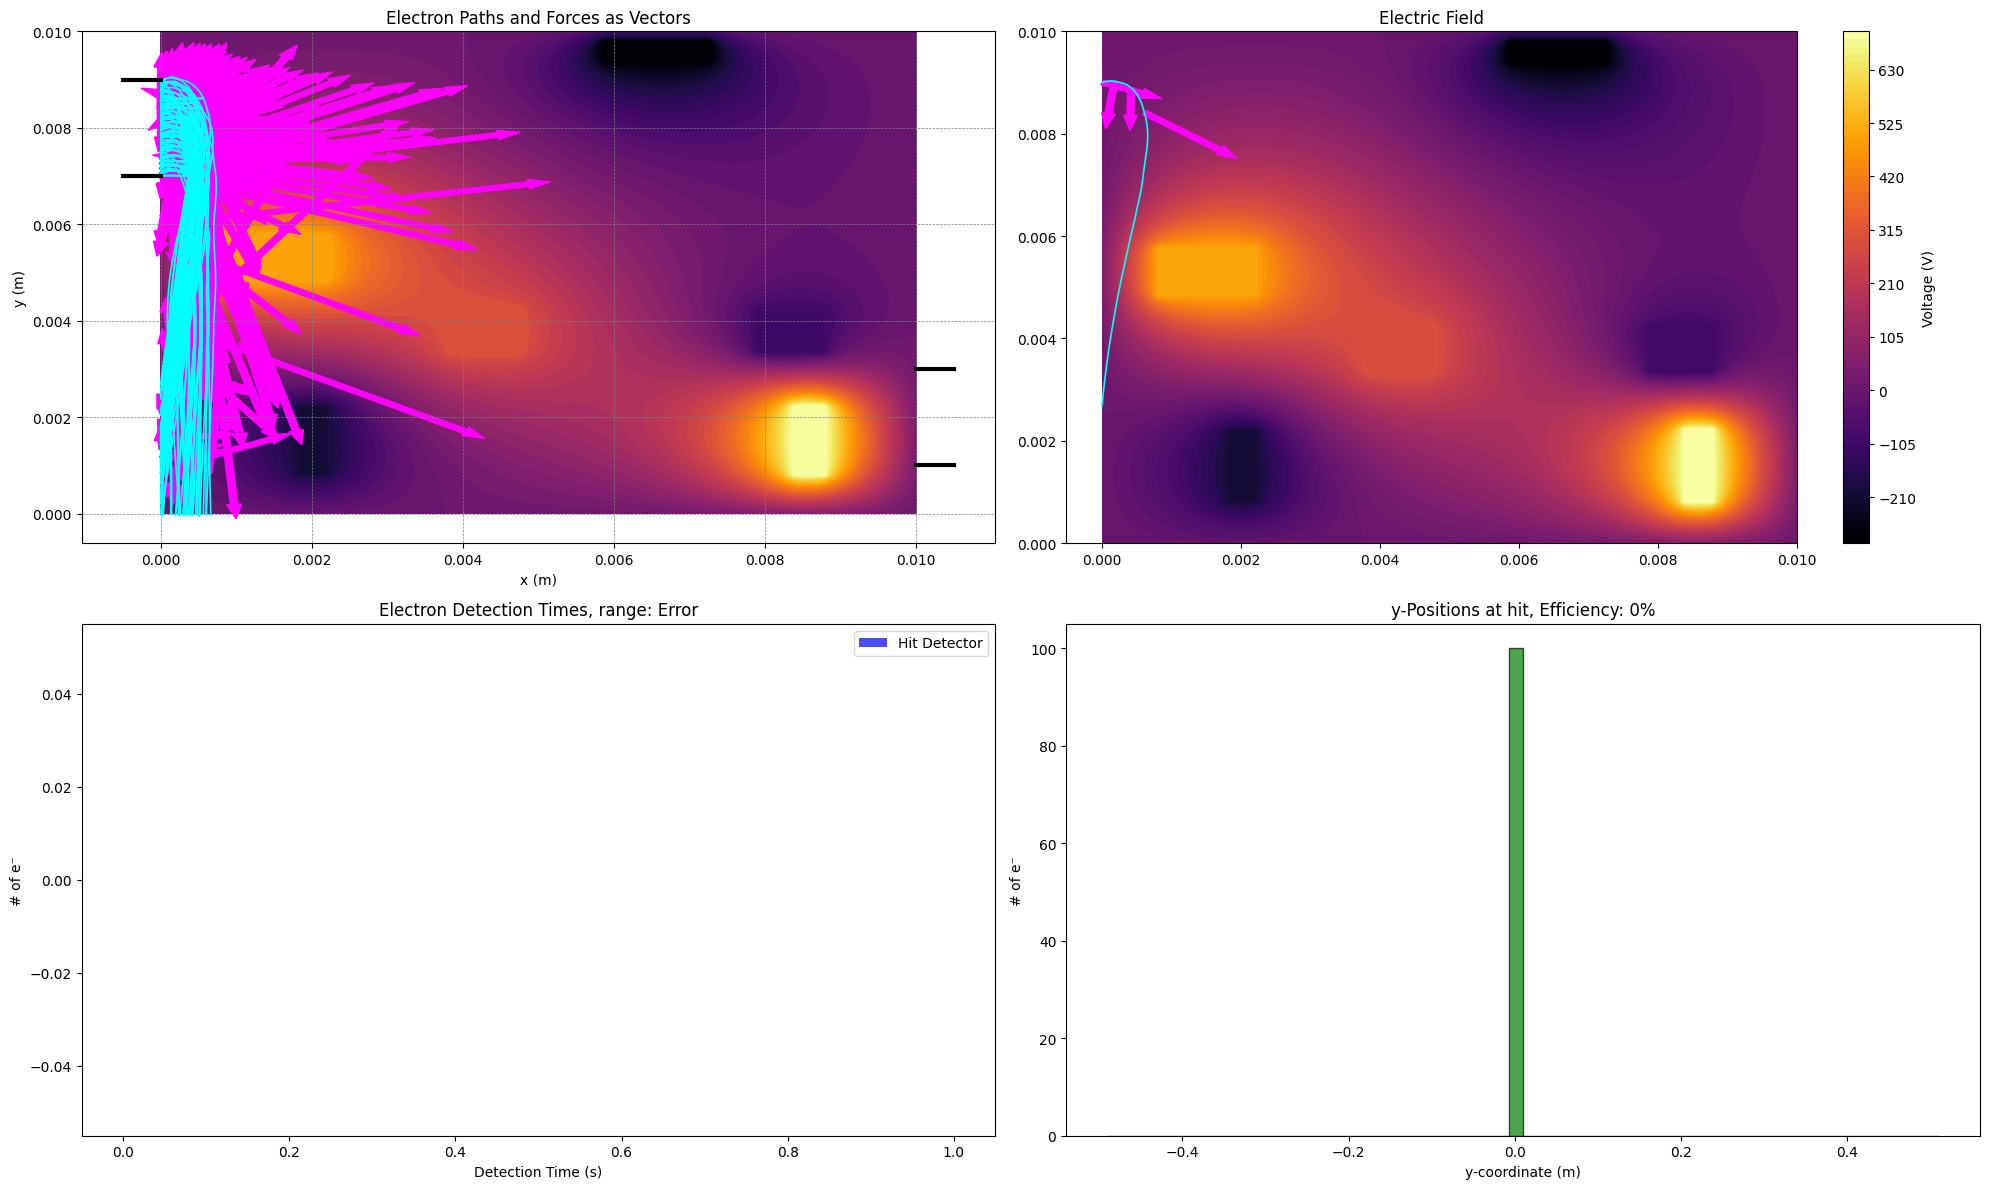

In [229]:
illustrate_electric_fields_and_paths(U_bicubic, xdata_ls, ydata_ls, force_x_ls, force_y_ls, t_hist, y_hist)
